## Comparative analysis of LST estimations in Bologna

Comparison between the RF model trained with high-resolution data (UAV)
and the RF model trained with open global data.

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

In [6]:
# --- input paths ---
lst_observed          = '../../datos-notebooks/3.HR-data-bologna/3.0.base-data/LST/LST_clipped_celsius.tif'
lst_predicted_hr      = '../../datos-notebooks/3.HR-data-bologna/3.4.LST-prediction/LST_predicted_RF.tif'
lst_predicted_global  = '../../datos-notebooks/2.global-data-bologna/LST-prediction/LST_predicted_RF.tif'

# --- output paths ---
output_folder = '../../datos-notebooks/4.comparative-analysis/'
os.makedirs(output_folder, exist_ok=True)
out_diff      = os.path.join(output_folder, 'LST_difference_bologna.tif')
out_fig_maps  = os.path.join(output_folder, 'mapas_lst_comparacion.png')
out_fig_diff  = os.path.join(output_folder, 'diff_lst_hr_global.png')
out_fig_thr   = os.path.join(output_folder, 'umbral_lst.png')

In [7]:
def quantify(o, p, nodata=None):
    """Computes error metrics between observed (o) and predicted (p) LST."""
    mask = np.isfinite(o) & np.isfinite(p)
    if nodata is not None:
        mask &= (o != nodata)
    o, p = o[mask], p[mask]
    print(f"  Bias  : {np.mean(p - o):.3f} °C")
    print(f"  MAE   : {np.mean(np.abs(p - o)):.3f} °C")
    print(f"  RMSE  : {np.sqrt(np.mean((p - o)**2)):.3f} °C")
    print(f"  r     : {np.corrcoef(o, p)[0, 1]:.3f}")

### 1. Error metrics with respect to the observed LST

In [8]:
with rasterio.open(lst_observed) as s0:
    obs  = s0.read(1).astype('float32')
    nd   = s0.nodata

with rasterio.open(lst_predicted_hr) as s1:
    hr   = s1.read(1).astype('float32')

with rasterio.open(lst_predicted_global) as s2:
    glob = s2.read(1).astype('float32')

print('── HR model (UAV data) ─────────────────────────────')
quantify(obs, hr, nd)

print('── Global model (open data) ────────────────────────')
quantify(obs, glob, nd)

── Modelo HR (datos VANT) ──────────────────────────
  Bias  : 0.002 °C
  MAE   : 0.761 °C
  RMSE  : 1.054 °C
  r     : 0.944
── Modelo global (datos abiertos) ──────────────────
  Bias  : -0.000 °C
  MAE   : 0.685 °C
  RMSE  : 0.957 °C
  r     : 0.954


### 2. Comparative maps: observed, HR and global LST

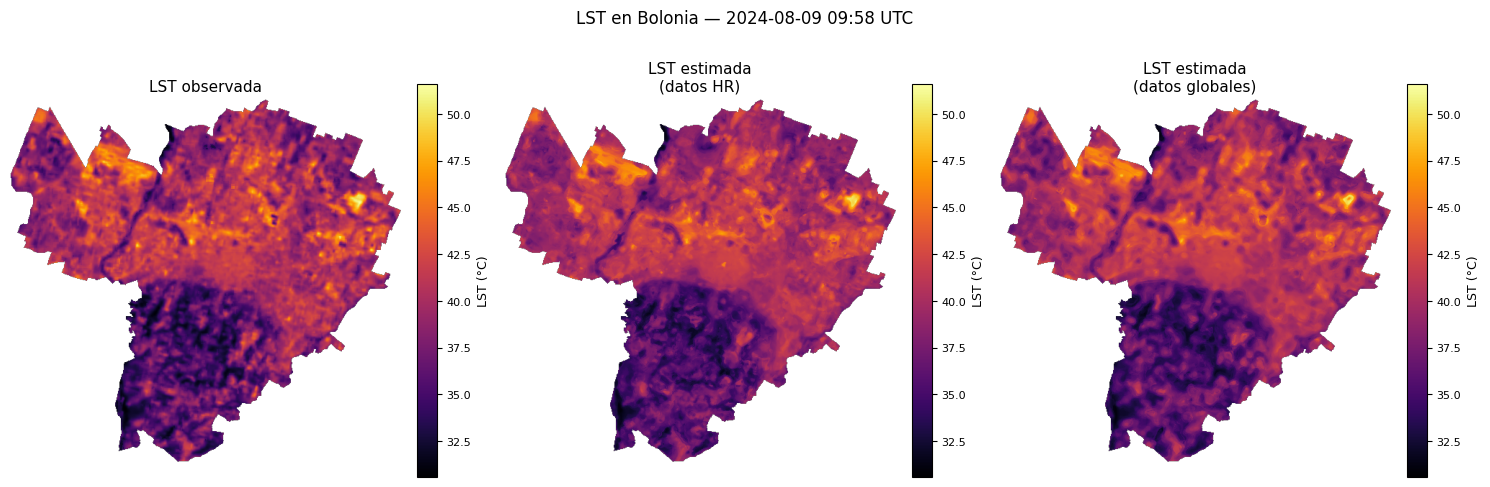

Guardado: ../../datos-notebooks/4.comparative-analysis/mapas_lst_comparacion.png


In [9]:
vmin = float(np.nanmin(obs))
vmax = float(np.nanmax(obs))

titles  = ['LST observada', 'LST estimada\n(datos HR)', 'LST estimada\n(datos globales)']
arrays  = [obs, hr, glob]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, arr, title in zip(axes, arrays, titles):
    im = ax.imshow(arr, cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('LST (°C)', fontsize=9)
    cb.ax.tick_params(labelsize=8)

plt.suptitle('LST en Bolonia — 2024-08-09 09:58 UTC', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(out_fig_maps, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', out_fig_maps)

### 3. Spatial difference between predictions (HR − Global)

In [10]:
diff = hr - glob

# Save difference raster
with rasterio.open(lst_predicted_hr) as src:
    profile = src.profile.copy()
profile.update(dtype='float32')
with rasterio.open(out_diff, 'w', **profile) as dst:
    dst.write(diff, 1)
print('Difference raster saved in:', out_diff)

Raster de diferencias guardado en: ../../datos-notebooks/4.comparative-analysis/LST_difference_bologna.tif


In [11]:
# Difference statistics
mask_d = np.isfinite(diff)
d = diff[mask_d]

print(f'Mean       : {np.mean(d):.3f} °C')
print(f'Median     : {np.median(d):.3f} °C')
print(f'Std. dev.  : {np.std(d):.3f} °C')
print(f'MAE        : {np.mean(np.abs(d)):.3f} °C')
print(f'RMSE       : {np.sqrt(np.mean(d**2)):.3f} °C')

Media      : 0.002 °C
Mediana    : -0.008 °C
Desv. est. : 0.851 °C
MAE        : 0.613 °C
RMSE       : 0.851 °C


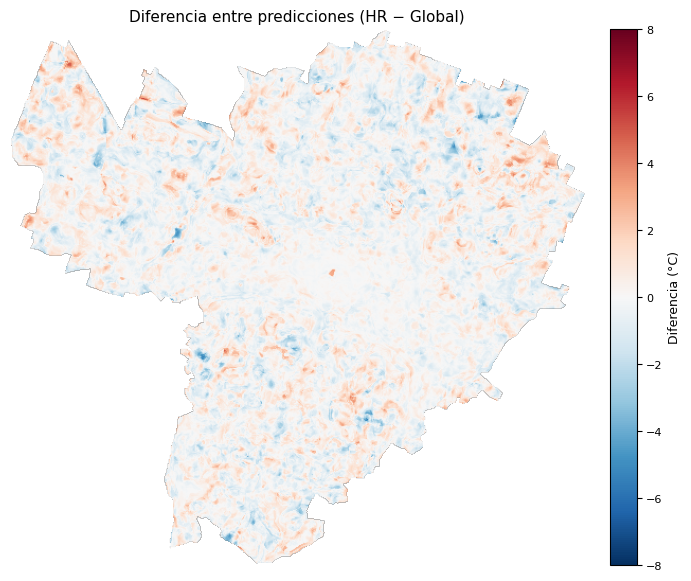

Guardado: ../../datos-notebooks/4.comparative-analysis/diff_lst_hr_global.png


In [12]:
# Difference map
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(diff, cmap='RdBu_r', vmin=-8, vmax=8)
ax.axis('off')
ax.set_title('Diferencia entre predicciones (HR − Global)', fontsize=11)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
cb.set_label('Diferencia (°C)', fontsize=9)
cb.ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(out_fig_diff, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', out_fig_diff)

### 4. Percentage of pixels per absolute difference threshold

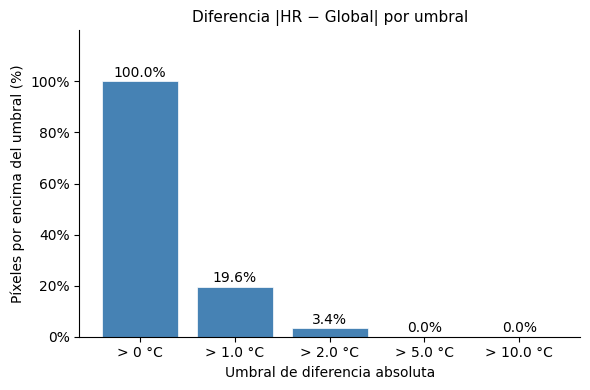

Guardado: ../../datos-notebooks/4.comparative-analysis/umbral_lst.png


In [13]:
thresholds = [0,1.0, 2.0, 5.0, 10.0]
fractions  = [float(np.mean(np.abs(d) > thr) * 100) for thr in thresholds]
labels     = [f'> {t} °C' for t in thresholds]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, fractions, color='steelblue', edgecolor='white', linewidth=0.5)

# Values above each bar
for bar, val in zip(bars, fractions):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_xlabel('Umbral de diferencia absoluta', fontsize=10)
ax.set_ylabel('Píxeles por encima del umbral (%)', fontsize=10)
ax.set_title('Diferencia |HR − Global| por umbral', fontsize=11)
ax.set_ylim(0, max(fractions) * 1.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(out_fig_thr, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', out_fig_thr)

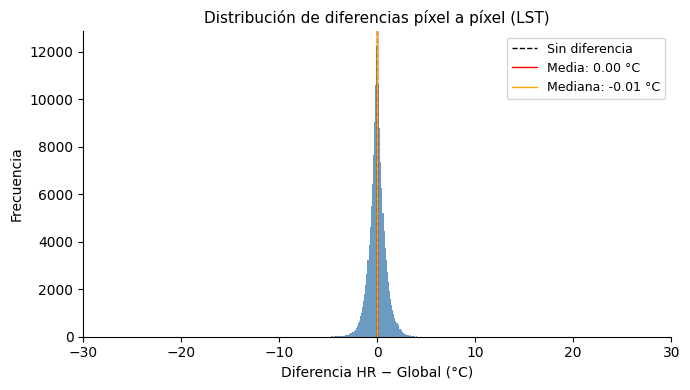

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(d, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='Sin diferencia')
ax.axvline(np.mean(d), color='red', linewidth=1, linestyle='-', label=f'Media: {np.mean(d):.2f} °C')
ax.axvline(np.median(d), color='orange', linewidth=1, linestyle='-', label=f'Mediana: {np.median(d):.2f} °C')

ax.set_xlabel('Diferencia HR − Global (°C)', fontsize=10)
ax.set_ylabel('Frecuencia', fontsize=10)
ax.set_title('Distribución de diferencias píxel a píxel (LST)', fontsize=11)
ax.set_xlim(-30, 30)  # adjust according to your data
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()